In [1]:
import pandas as pd

df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data2.csv", parse_dates=["date"])

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\manoj\AppData\Local\Temp\ipykernel_8288\1420813484.py:3: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("D:\mycode\Fintech-agent\data\macro\combined_macro_data2.csv", parse_dates=["date"])


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet, BayesianRidge
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error,  mean_absolute_percentage_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, PolynomialFeatures
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
import warnings
from sklearn.inspection import permutation_importance

In [8]:
def rf_msp_prediction(data, use_macro, model,
                         use_scaling, scaler_type,
                         test_quarters=4):

    macro_vars = ["YLDMAT","DAYMAT","b30ret","b30ind","b20ret","b20ind","b10ret","b10ind",
        "b7ret","b7ind","b5ret","b5ind","b2ret","b2ind","b1ret","b1ind","t90ret",
        "t90ind","t30ret","t30ind","cpiret","cpiind","wti_price","trade_balance",
        "eci","gdp","gscpi","long_term_rate","median_cpi","nfci","anfci","nfci_risk",
        "nfci_credit","nfci_leverage","nfci_nonfinancial_leverage","ppi","real_property_price",
        "unrate"
    ]

    df = data.copy()
    df = df.sort_values("date")
    dates = df["date"]

    X = df.drop(columns=["Median Sale Price", "date"])
    y = df["Median Sale Price"]

    if not use_macro:
        X = X.drop(columns=macro_vars, errors="ignore")

    X_train = X.iloc[:-test_quarters]
    X_test  = X.iloc[-test_quarters:]
    y_train = y.iloc[:-test_quarters]
    y_test  = y.iloc[-test_quarters:]
    test_dates = dates.iloc[-test_quarters:]
    feature_names = X.columns.tolist()

    steps = []
    if use_scaling:
        scalers = {
            'standard': StandardScaler(),
            'robust':   RobustScaler(),
            'minmax':   MinMaxScaler()
        }
        steps.append(('scaler', scalers.get(scaler_type, StandardScaler())))

    if model == 'RF':
        regressor = RandomForestRegressor(n_estimators=500, random_state=42)
    elif model == 'GB':
        regressor = GradientBoostingRegressor(
            n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
        )
    elif model == 'XGB':
        regressor = XGBRegressor(
            n_estimators=500, learning_rate=0.05, max_depth=3,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, objective='reg:squarederror'
        )
    elif model == 'KNN':
        regressor = KNeighborsRegressor(n_neighbors=5, weights='distance')
    elif model == 'SVR':
        regressor = SVR(kernel='rbf', C=1.0, epsilon=0.1)
    elif model == 'bayes':
        regressor = BayesianRidge()
    elif model == 'catboost':
        regressor = CatBoostRegressor(
            iterations=500, learning_rate=0.03, depth=4,
            l2_leaf_reg=3.0, random_state=42, verbose=0
        )

    steps.append(('model', regressor))
    pipeline = Pipeline(steps)
    pipeline.fit(X_train, y_train)

    predictions  = pipeline.predict(X_test)
    fitted_model = pipeline.named_steps['model']


    mse = mean_squared_error(y_test, predictions)
    r2  = r2_score(y_test, predictions)

    results = pd.DataFrame({
        "date":             test_dates.values,
        "actual_msp":    y_test.values,
        "predicted_msp": predictions
    })
    print(f"\n{'='*55}")
    print(f"{'Date':<15} {'Actual':>12} {'Predicted':>12} {'Error':>12}")
    print(f"{'-'*55}")
    for _, row in results.iterrows():
        error = abs(row['actual_msp'] - row['predicted_msp'])
        print(f"{row['date'].strftime('%Y-%m-%d'):<15} {row['actual_msp']:>12.6f} {row['predicted_msp']:>12.6f} {error:>12.6f}")
    print(f"{'-'*55}")
    print(f"{'MSE:':>40} {mse:>12.6f}")
    print(f"{'R²:':>40} {r2:>12.4f}")
    print(f"{'='*55}")

    if hasattr(fitted_model, 'feature_importances_'):
        importances = fitted_model.feature_importances_
    elif hasattr(fitted_model, 'coef_'):
        importances = np.abs(fitted_model.coef_)
    else:
        perm = permutation_importance(pipeline, X_train, y_train,
                                             n_repeats=20, random_state=42)
        importances = perm.importances_mean

    fi_df = pd.DataFrame({
        'feature':    feature_names,
        'importance': importances
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    # Split into macro vs other
    macro_fi = fi_df[fi_df['feature'].isin(macro_vars)].reset_index(drop=True)
    other_fi = fi_df[~fi_df['feature'].isin(macro_vars)].reset_index(drop=True)

    n_plots = 2 + (1 if use_macro and not macro_fi.empty else 0) + (1 if not other_fi.empty else 0)
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))
    axes = np.array(axes).flatten()

    ax_idx = 0

    x = range(len(results))
    axes[ax_idx].plot(x, results["actual_msp"],    marker="o", label="Actual",    linewidth=2)
    axes[ax_idx].plot(x, results["predicted_msp"], marker="o", label="Predicted", linewidth=2)
    axes[ax_idx].set_xticks(x)
    axes[ax_idx].set_xticklabels(results["date"].dt.strftime('%Y-%m-%d'), rotation=45)
    axes[ax_idx].set_xlabel("Quarter")
    axes[ax_idx].set_ylabel("msp")
    axes[ax_idx].set_title(f"msp Prediction — {model}\n(R²={r2:.3f}  MSE={mse:.6f})")
    axes[ax_idx].legend()
    axes[ax_idx].grid(True, alpha=0.3)
    ax_idx += 1

    # Macro importance
    if use_macro and not macro_fi.empty:
        axes[ax_idx].barh(macro_fi['feature'][::-1], macro_fi['importance'][::-1], color='steelblue')
        axes[ax_idx].set_title(f"Macro Variable Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    #  Other features importance 
    if not other_fi.empty:
        axes[ax_idx].barh(other_fi['feature'][::-1], other_fi['importance'][::-1], color='darkorange')
        axes[ax_idx].set_title(f"Other Feature Importance\n({model})")
        axes[ax_idx].set_xlabel("Importance")
        axes[ax_idx].grid(True, alpha=0.3)
        ax_idx += 1

    for j in range(ax_idx, len(axes)):
        axes[j].set_visible(False)

    macro_label = "With Macro" if use_macro else "Without Macro"
    plt.suptitle(f"{model} | {macro_label} | Scaler: {scaler_type}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return results, mse, r2

### bayes


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 416797.619220 136059.523637
2024-06-30      596285.714286 416797.619705 179488.094581
2024-09-30      587238.095238 416797.619336 170440.475902
2024-12-31      576619.047619 416797.619082 159821.428537
-------------------------------------------------------
                                    MSE: 26330253728.462303
                                     R²:     -98.9696


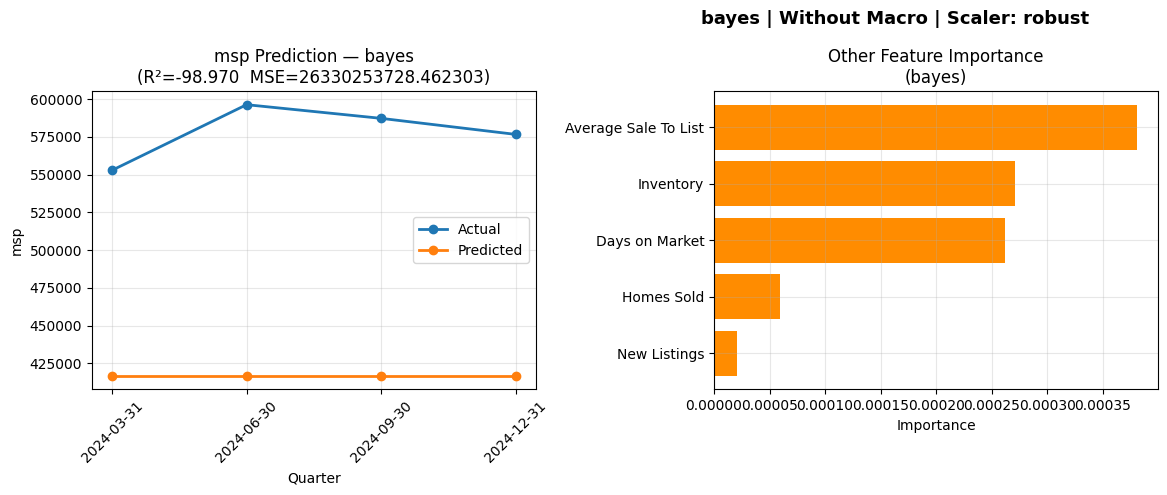

In [9]:

# Usage
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='bayes',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 552111.482427   745.660430
2024-06-30      596285.714286 585012.079008 11273.635278
2024-09-30      587238.095238 575903.749736 11334.345502
2024-12-31      576619.047619 567727.581779  8891.465840
-------------------------------------------------------
                                    MSE: 83794103.651586
                                     R²:       0.6819


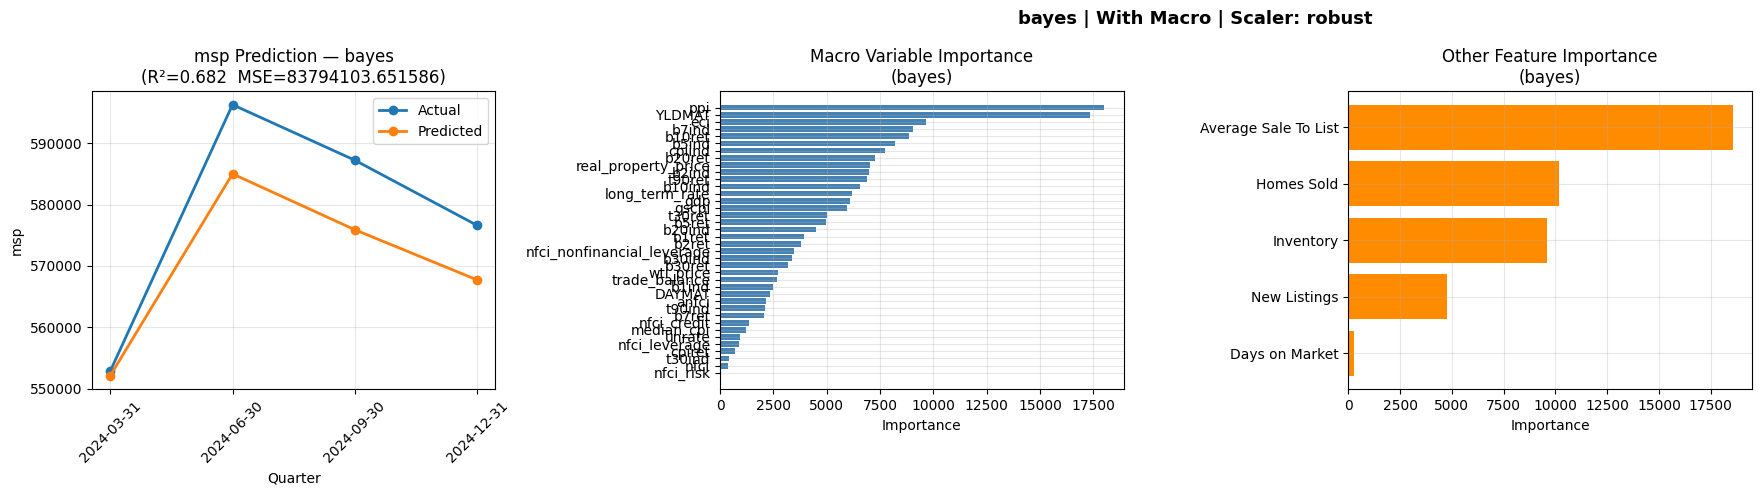

In [5]:

# Usage
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='bayes',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### Random Forest


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 522876.571429 29980.571429
2024-06-30      596285.714286 519226.190476 77059.523810
2024-09-30      587238.095238 409115.904762 178122.190476
2024-12-31      576619.047619 489150.095238 87468.952381
-------------------------------------------------------
                                    MSE: 11553834310.898222
                                     R²:     -42.8671


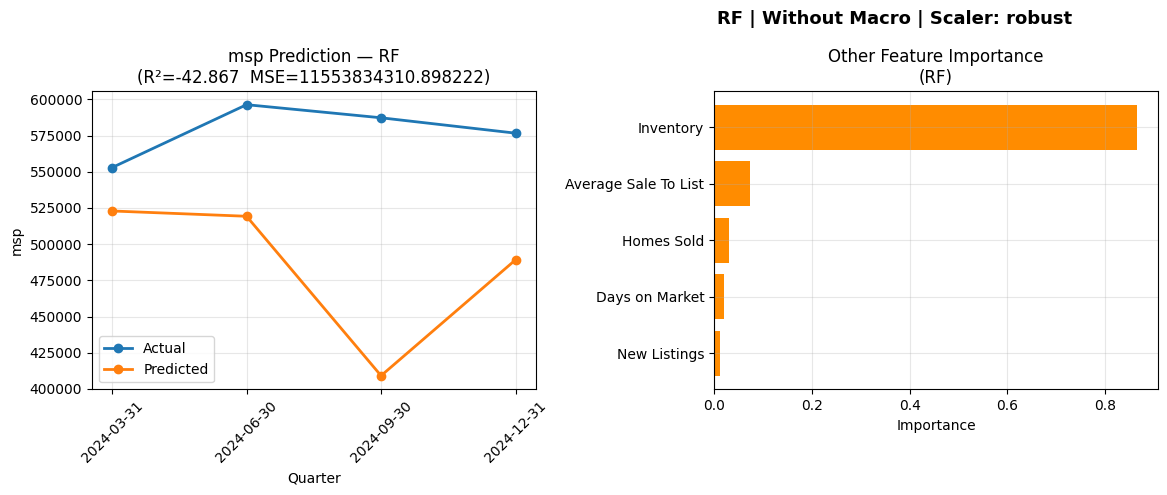

In [7]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='RF',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 538282.857143 14574.285714
2024-06-30      596285.714286 540017.047619 56268.666667
2024-09-30      587238.095238 514772.095238 72466.000000
2024-12-31      576619.047619 533152.571429 43466.476190
-------------------------------------------------------
                                    MSE: 2629807090.235829
                                     R²:      -8.9847


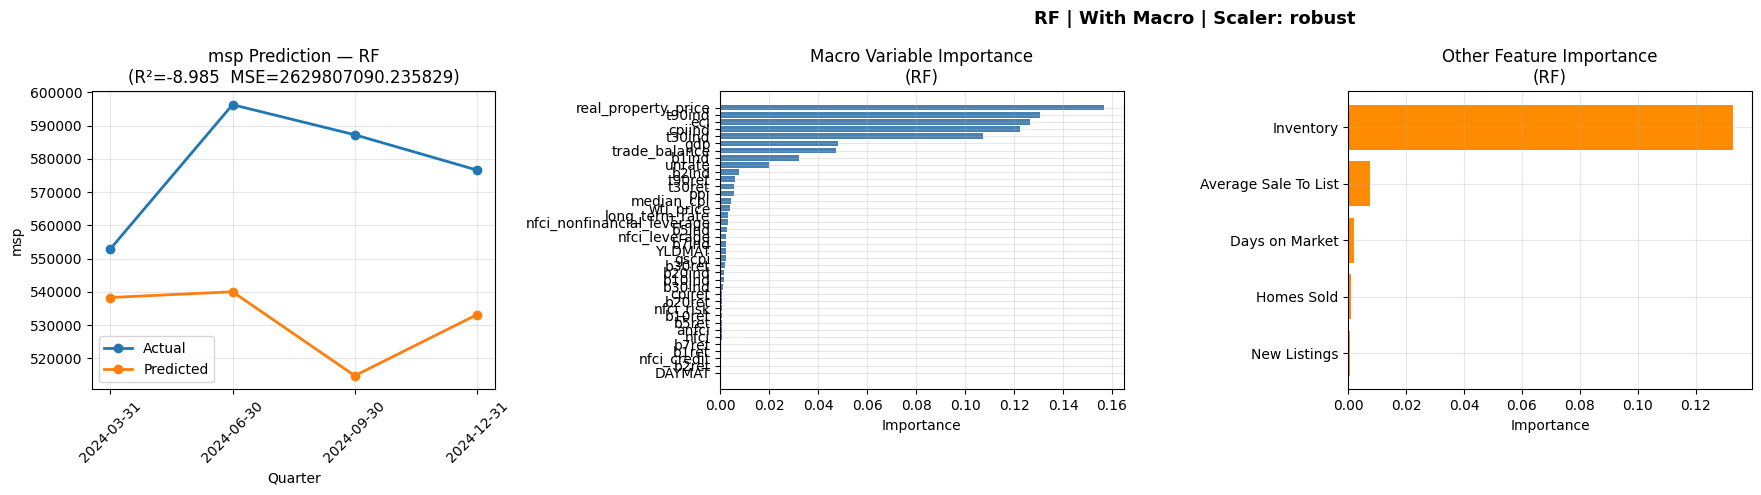

In [8]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='RF',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### XGB


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 527578.937500 25278.205357
2024-06-30      596285.714286 553233.437500 43052.276786
2024-09-30      587238.095238 428633.125000 158604.970238
2024-12-31      576619.047619 519188.968750 57430.078869
-------------------------------------------------------
                                    MSE: 7736559186.410938
                                     R²:     -28.3739


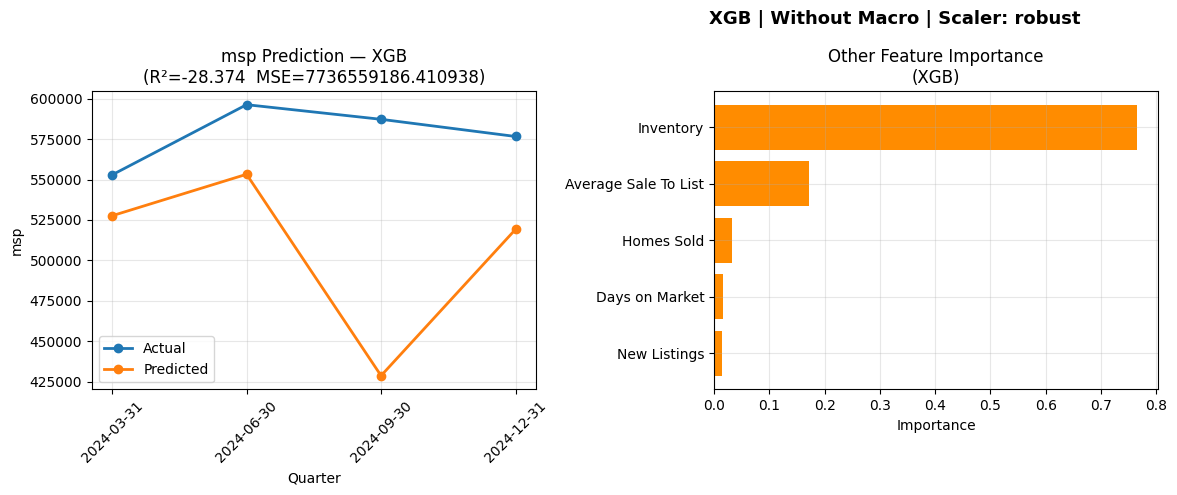

In [9]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 536059.937500 16797.205357
2024-06-30      596285.714286 544238.125000 52047.589286
2024-09-30      587238.095238 544350.562500 42887.532738
2024-12-31      576619.047619 542599.375000 34019.672619
-------------------------------------------------------
                                    MSE: 1496944061.933200
                                     R²:      -4.6835


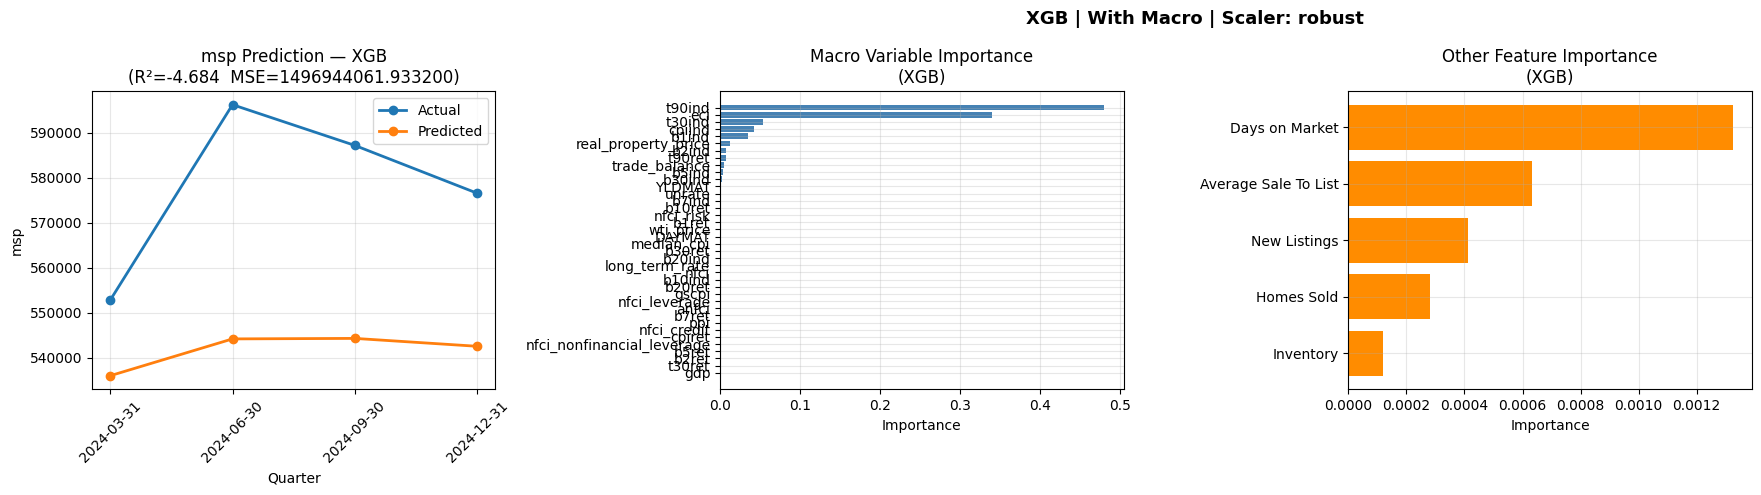

In [10]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='XGB',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### KNN


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 505116.518891 47740.623966
2024-06-30      596285.714286 535243.159579 61042.554707
2024-09-30      587238.095238 517540.967696 69697.127542
2024-12-31      576619.047619 476140.100295 100478.947324
-------------------------------------------------------
                                    MSE: 5239767276.232944
                                     R²:     -18.8941


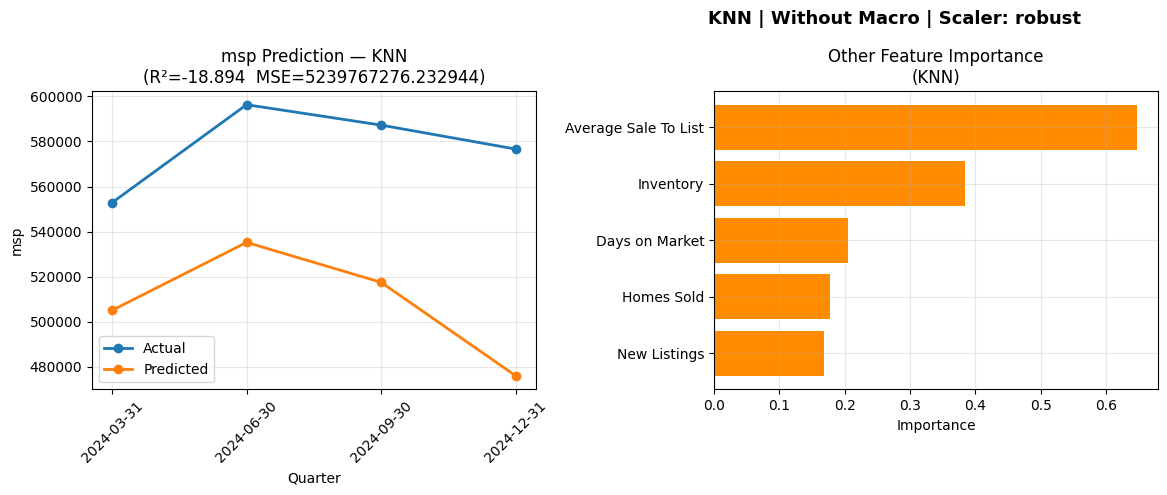

In [11]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='KNN',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 519140.308530 33716.834327
2024-06-30      596285.714286 540295.848915 55989.865371
2024-09-30      587238.095238 515868.764941 71369.330297
2024-12-31      576619.047619 541266.046197 35353.001422
-------------------------------------------------------
                                    MSE: 2653776489.471762
                                     R²:      -9.0758


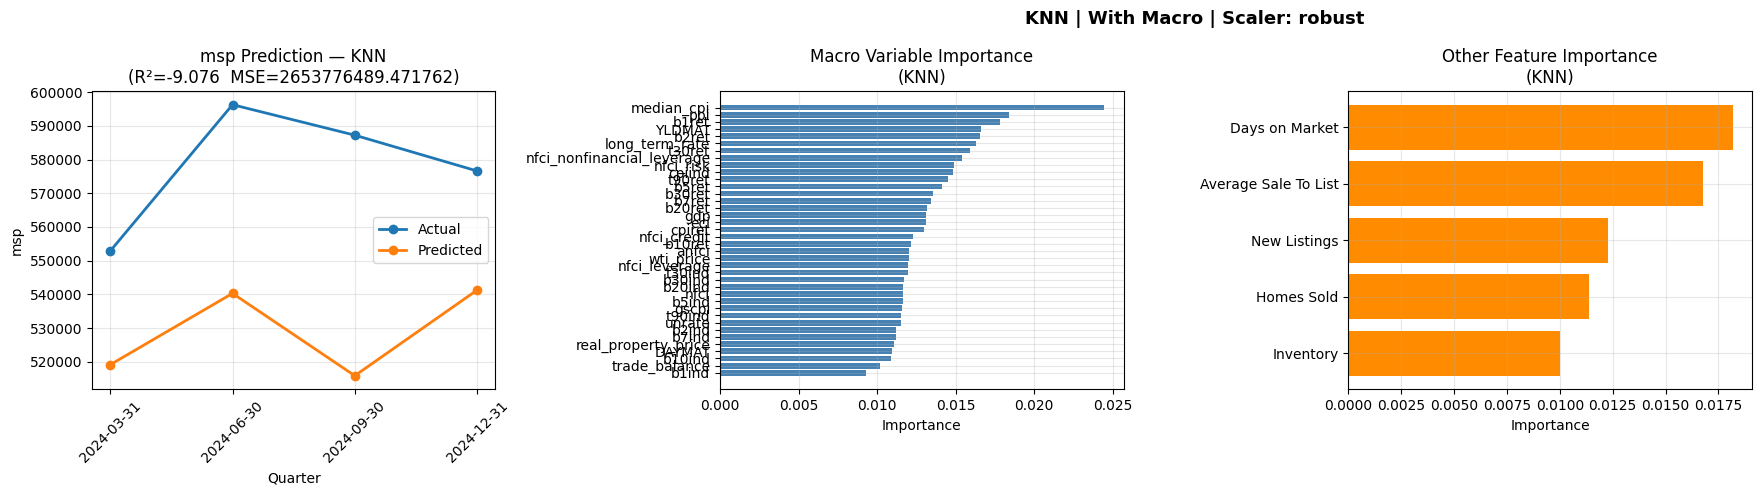

In [12]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='KNN',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### SVR


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 404148.095471 148709.047387
2024-06-30      596285.714286 404151.046690 192134.667596
2024-09-30      587238.095238 404148.539937 183089.555302
2024-12-31      576619.047619 404146.840728 172472.206891
-------------------------------------------------------
                                    MSE: 30574639669.292568
                                     R²:    -115.0845


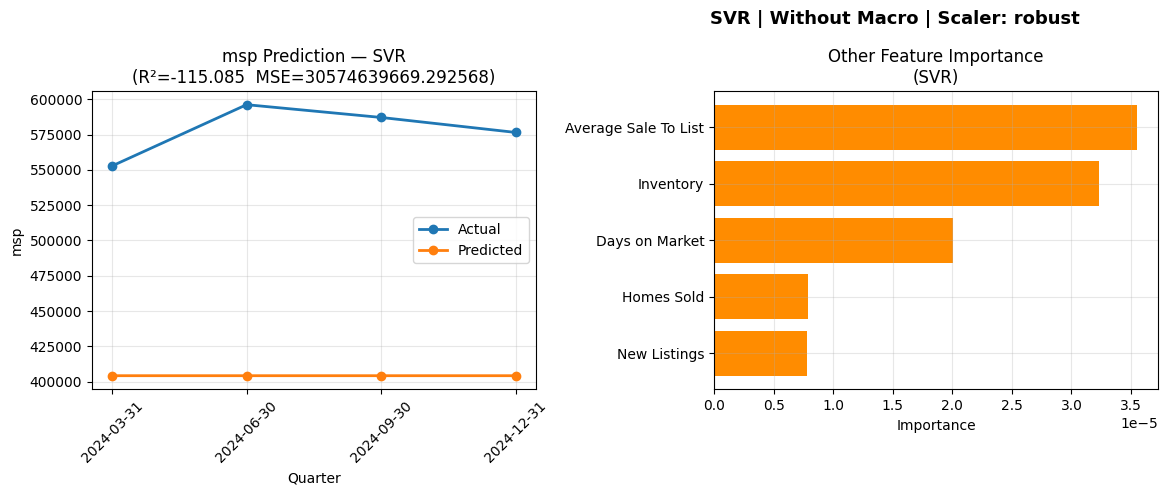

In [14]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='SVR',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 404149.984772 148707.158085
2024-06-30      596285.714286 404150.292513 192135.421773
2024-09-30      587238.095238 404149.243027 183088.852211
2024-12-31      576619.047619 404149.532635 172469.514984
-------------------------------------------------------
                                    MSE: 30574275142.009178
                                     R²:    -115.0832


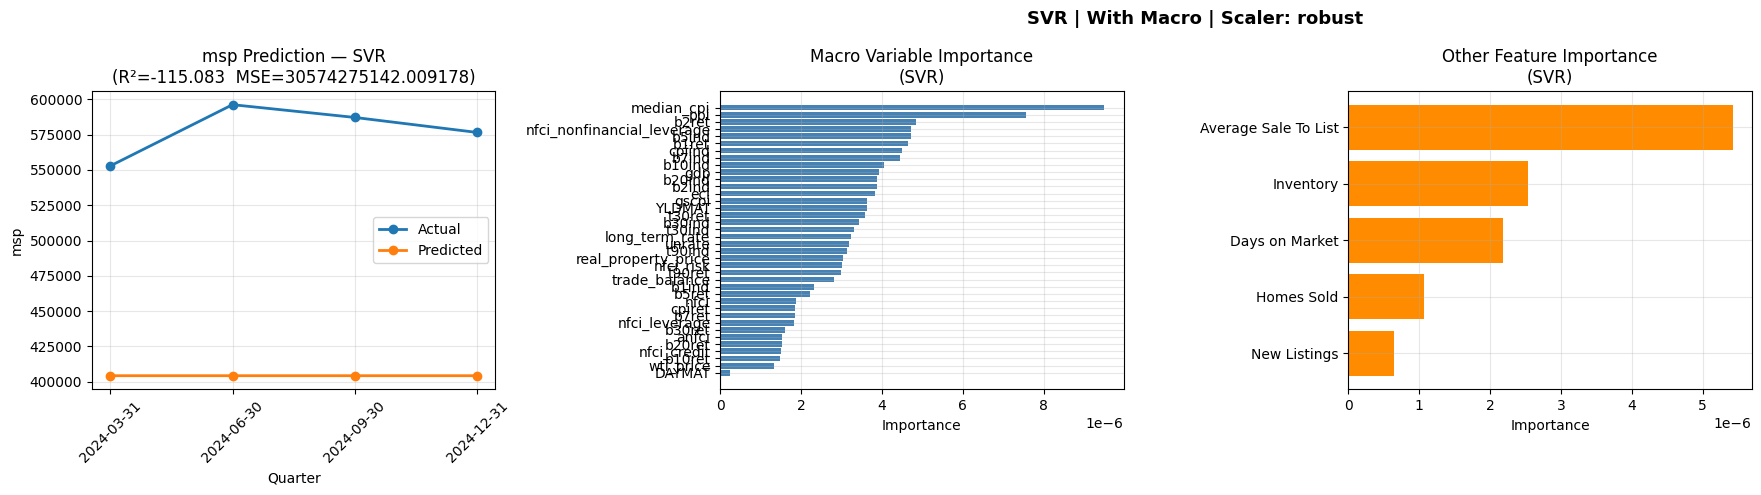

In [16]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='SVR',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)

### Catboost


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 527827.687067 25029.455790
2024-06-30      596285.714286 526257.543008 70028.171277
2024-09-30      587238.095238 427585.920462 159652.174776
2024-12-31      576619.047619 509540.863171 67078.184448
-------------------------------------------------------
                                    MSE: 8879679542.303347
                                     R²:     -32.7140


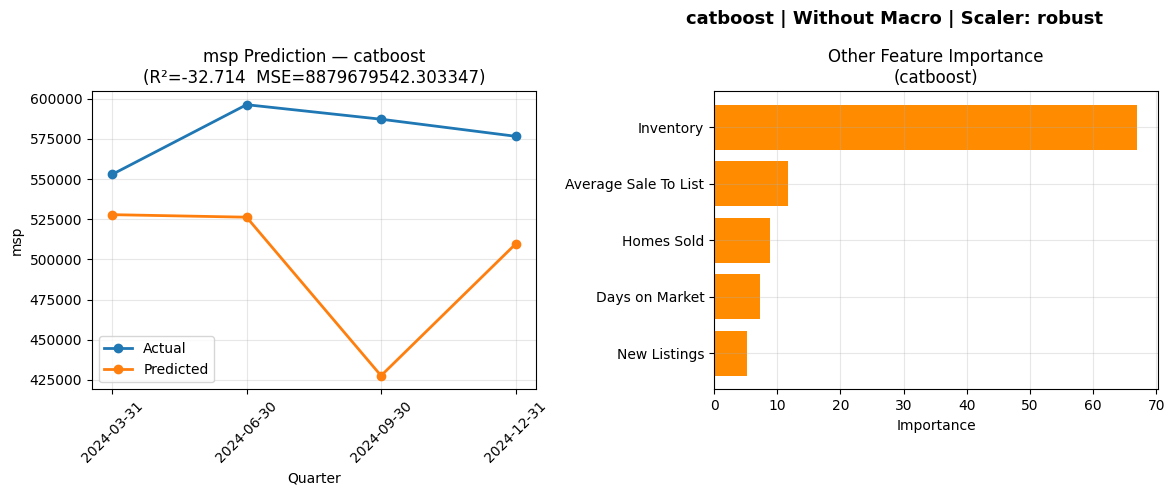

In [17]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=False,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)


Date                  Actual    Predicted        Error
-------------------------------------------------------
2024-03-31      552857.142857 540655.035218 12202.107639
2024-06-30      596285.714286 544542.933117 51742.781169
2024-09-30      587238.095238 514089.323778 73148.771460
2024-12-31      576619.047619 536182.301827 40436.745792
-------------------------------------------------------
                                    MSE: 2453020002.578379
                                     R²:      -8.3135


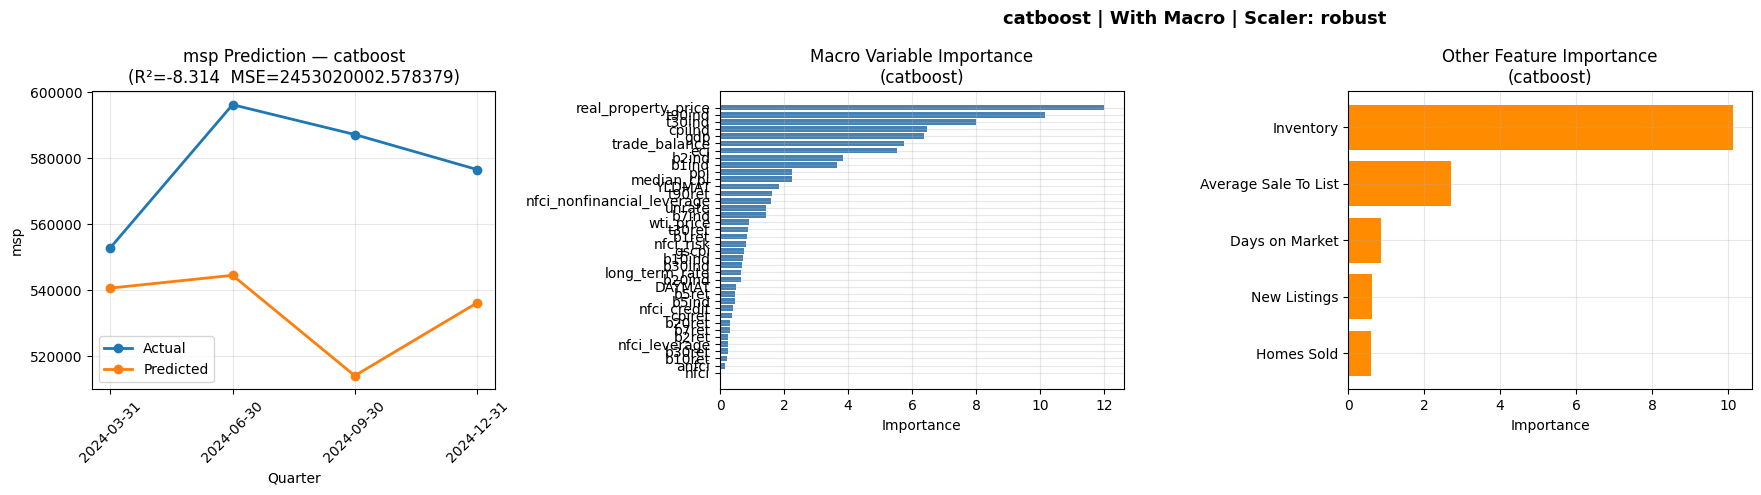

In [18]:
results, mse, r2 = rf_msp_prediction(
    df,
    use_macro=True,
    model='catboost',
    use_scaling=True,
    scaler_type='robust',
    test_quarters=4
)